In [309]:
import os
import datetime
from Functions.Utils import *
from Functions.Graphs import *
import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns; sns.set_theme()
from os.path import expanduser
from os import stat
from glob import glob
from pandas import Timestamp
from numpy import sin, cos, pi
from numpy import array, copy, mean, std
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, InputLayer
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

np.random.seed(7)
tf.random.set_seed(7)


mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

def plot(history):
    # summarize history for loss
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    losses = [('loss', 'val_loss'), ('root_mean_squared_error', 'val_root_mean_squared_error')]
    for i in range(2):
        ax[i].plot(history.history[losses[i][0]])
        ax[i].plot(history.history[losses[i][1]])
        ax[i].set_title('Loss - '+losses[i][0])
        ax[i].set_ylabel('loss')
        ax[i].set_xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper right')
    plt.show()

In [275]:
def exponential_moving_average_df2(df, alpha=0.3):
    ema_df = df.copy()
    for i,col in enumerate(df.columns):
        if i < len(df.columns)-1:
            ema_df[col] = exponential_moving_average(df[col], alpha)
        else:
            ema_df[col] = df[col]
    return ema_df


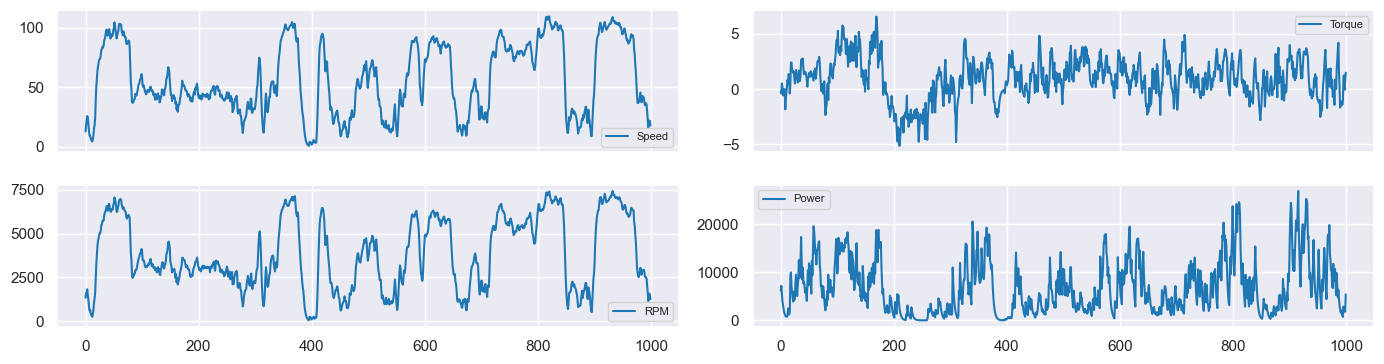

In [302]:
dfs = [pd.DataFrame() for i in range(3)]
paths = [r'Datasets\DEVRT\NISSAN_LEAF_TRAIN',r'Datasets\DEVRT\NISSAN_LEAF_TEST', r'Datasets\DEVRT\NISSAN_LEAF_VAL']
column_names = ['Elv', 'Speed', 'AmbTemp', 'Regenwh', 'MotorTemp', 'Torque', 'RPM', 'Power']
column_names = ['Elv', 'Speed', 'AmbTemp', 'Regenwh', 'Torque', 'RPM', 'Power']
column_names = ['Elv', 'Speed', 'AmbTemp', 'Torque', 'RPM', 'Power']
column_names = ['Speed', 'Torque', 'RPM', 'Power']
for i,path in enumerate(paths):
    samples = os.listdir(path)
    for sample in samples[:]:
        df = pd.read_csv(os.path.join(path,sample))
        df = df.ffill().bfill()
        pwr = df['Motor Pwr(w)'].values
        df = df.drop(columns=['timestamp_data_utc','timestamp_gps_utc', 'car_id', 'time_diff', 'point_geom', 'route_code',
        'route_description', 'driver', 'start_timestamp', 'end_timestamp','car_code', 'car_description', 'ref_consumption',
        'timestamp_weather_utc','wind_mph', 'wind_kph', 'wind_degree','wind_dir', 'Frontal_Wind', 'Veh_deg', 'totalVehicles', 'speedAvg',
        'cars_by_speed_interval_0_80', 'cars_by_speed_interval_80_100','cars_by_speed_interval_100_120', 'cars_by_speed_interval_0_50',
        'cars_by_speed_interval_50_80', 'cars_by_speed_interval_80_120','cars_by_speed_interval_120_inf', 'cars_by_length_interval_0_7',
        'cars_by_length_interval_7_inf', 'max_speed', 'route_id','Aux Pwr(100w)','capacity', 'soh','soc','radius',
        'longitude', 'latitude', 'altitude', 'cumul_dist','Motor Temp','regenwh','elv_spy','amb_temp','Motor Pwr(w)'])
        df['Motor Pwr(w)'] = pwr
        #df = moving_average_df(df,5)
        #df = exponential_moving_average_df2(df,0.3)
        dfs[i] = pd.concat([dfs[i],df])
    pwr = dfs[i]['Motor Pwr(w)'].values[1:]
    dfs[i] = dfs[i].drop(columns=['Motor Pwr(w)'])
    dfs[i] = dfs[i][:-1].copy()
    dfs[i]['power'] = pwr
    dfs[i] = dfs[i].reset_index(drop=True)
    dfs[i].columns = column_names

for i in range(3):
    dfs[i] = exponential_moving_average_df(dfs[i],0.3)
train, test, val = dfs

PlotDataframes([train[:1000]],w=14,h=4,cols_qtd=2)

In [303]:
scaler = MinMaxScaler()
scaler.fit(train)
train_n = scaler.fit_transform(train)
test_n = scaler.fit_transform(test)
val_n = scaler.fit_transform(val)
train_df = pd.DataFrame(train_n, columns=column_names, index=train.index)
test_df = pd.DataFrame(test_n, columns=column_names, index=test.index)
val_df = pd.DataFrame(val_n, columns=column_names, index=val.index)


In [304]:
def df_to_tensor(df, window_size):
    data = df.to_numpy()
    X, y = [], []
    for i in range(data.shape[0]-window_size):
        row = [r[:-1] for r in data[i:i+window_size]]
        label = [data[i+window_size][-1]]
        X.append(row)
        y.append(label)
    return array(X), array(y)

In [305]:
WINDOW_SIZE = 50
X_train, y_train = df_to_tensor(train_df, WINDOW_SIZE)
X_test, y_test = df_to_tensor(test_df, WINDOW_SIZE)
X_val, y_val = df_to_tensor(val_df, WINDOW_SIZE)


In [282]:
model = Sequential()
model.add(InputLayer((X_train.shape[1], X_train.shape[2])))
model.add(LSTM(128, dropout=0.2))
#model.add(Dense(32, 'relu', kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01)))
model.add(Dense(8, 'relu', kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01)))
model.add(Dense(1, 'linear', kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01)))
model.summary()

Model: "sequential_19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_18 (LSTM)              (None, 128)               67584     
                                                                 
 dense_41 (Dense)            (None, 8)                 1032      
                                                                 
 dense_42 (Dense)            (None, 1)                 9         
                                                                 
Total params: 68,625
Trainable params: 68,625
Non-trainable params: 0
_________________________________________________________________


In [ ]:
print(X_train.shape, X_test.shape)

X_train2 = np.vstack((X_train,X_test))
y_train2 = np.vstack((y_train,y_test))
vSplit = X_test.shape[0]/X_train2.shape[0]

cp = ModelCheckpoint('model/', save_best_only=True)
es = EarlyStopping(patience=5, monitor='val_loss', mode='min', restore_best_weights=True, verbose=1)
model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0005), metrics=[RootMeanSquaredError()])
#history = model.fit(X_train2, y_train2, validation_split=vSplit, epochs=40, callbacks=[cp, es], shuffle=False)

history = model.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test), # Explicitly uses your dedicated validation tracks
    epochs=25, 
    batch_size=64,                 # Use an explicit batch size instead of defaulting to 32
    callbacks=[cp, es], 
    shuffle=True                    # It is now safe to shuffle windows to break temporal bias!
)

In [242]:
model = load_model('model/')

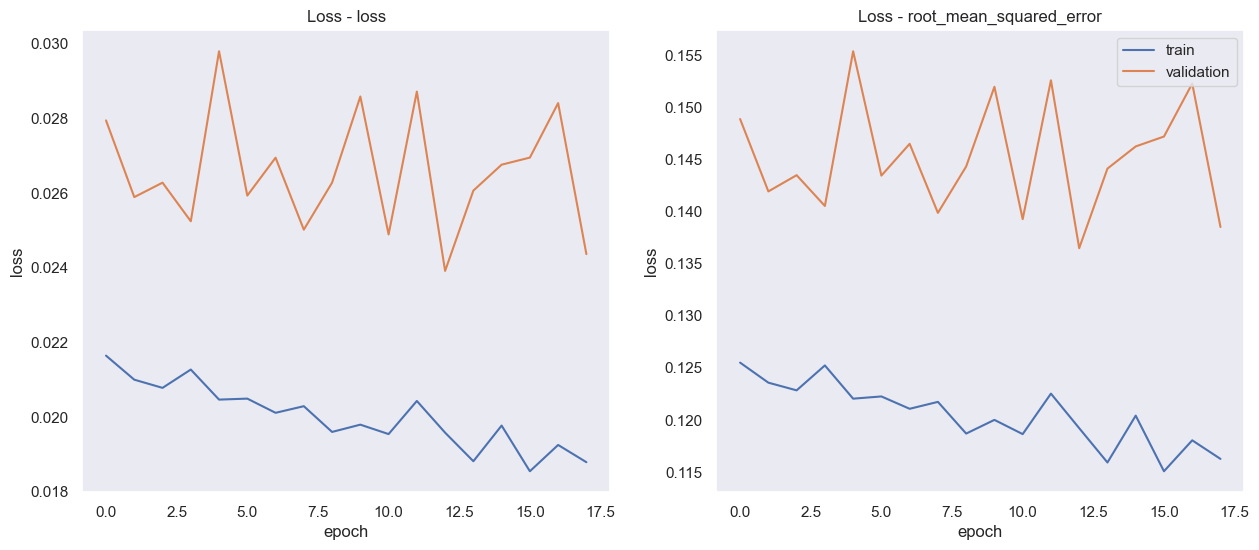

In [244]:
plot(history)

In [245]:
yP = np.array([])
yR = y_val[:].copy()
xR = X_val[:].copy()

yP = model.predict(xR)
PlotSeriesPLY(ySeries=[yR.flatten(),yP.flatten()])

11/11 [==============================] - 0s 17ms/step


In [306]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, InputLayer, LayerNormalization, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

# Fix random seed for reproducibility
np.random.seed(7)
tf.random.set_seed(7)

# --- 1. SLIDING WINDOW CONVERSION FUNCTION ---
def df_to_tensor(df, window_size):
    data = df.to_numpy()
    X, y = [], []
    for i in range(data.shape[0] - window_size):
        # Features take columns 0 to -2
        row = [r[:-1] for r in data[i:i+window_size]]
        # Label takes the last column (-1) at the target step
        label = [data[i+window_size][-1]]
        X.append(row)
        y.append(label)
    return np.array(X), np.array(y)

WINDOW_SIZE = 40 # Widened slightly to capture deeper vehicle momentum context

# Process separate tracking splits cleanly
X_train, y_train = df_to_tensor(train_df, WINDOW_SIZE)
X_val, y_val     = df_to_tensor(val_df, WINDOW_SIZE)
X_test, y_test   = df_to_tensor(test_df, WINDOW_SIZE)

# --- 2. OPTIMIZED MODEL ARCHITECTURE ---
model = Sequential()
model.add(InputLayer((X_train.shape[1], X_train.shape[2])))

# Upgraded width to 128 units and dropped recurrent_dropout for faster execution
model.add(LSTM(128, dropout=0.3, return_sequences=False))

# Layer Normalization stabilizes volatile telemetry signals before the dense mapping
model.add(LayerNormalization())
model.add(Dropout(0.2))

# Multi-Layer Non-Linear Regression Head
model.add(Dense(32, activation='relu', kernel_regularizer=l2(1e-4)))
model.add(Dense(16, activation='relu', kernel_regularizer=l2(1e-4)))
model.add(Dense(1, activation='linear'))

model.summary()

# --- 3. TRAINING SETTINGS & CALLBACKS ---
cp = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min')
es = EarlyStopping(patience=8, monitor='val_loss', mode='min', restore_best_weights=True, verbose=1)

# Dynamically lowers the learning rate if the validation curve plateaus
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

model.compile(
    loss=MeanSquaredError(), 
    optimizer=Adam(learning_rate=0.001), # Started slightly higher; scheduler handles decay
    metrics=[RootMeanSquaredError()]
)

# --- 4. EXECUTE COUPLING CONFIGURATION ---
history = model.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test), # Correctly passing true validation matrices
    epochs=40, 
    batch_size=128,                 # Large batch size ensures stable gradient transitions
    callbacks=[cp, es, lr_scheduler], 
    shuffle=True                    # Shuffling windows breaks chronological overfitting patterns
)

# --- 5. AUTHENTIC TEST DATASET EVALUATION ---
print("\nEvaluating model performance on completely unseen Test tracks...")
test_metrics = model.evaluate(X_val, y_val, verbose=0)
print(f"Final Out-of-Sample Test RMSE: {test_metrics[1]:.4f}")

Model: "sequential_24"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_23 (LSTM)              (None, 128)               67584     
                                                                 
 layer_normalization_7 (Laye  (None, 128)              256       
 rNormalization)                                                 
                                                                 
 dropout_7 (Dropout)         (None, 128)               0         
                                                                 
 dense_55 (Dense)            (None, 32)                4128      
                                                                 
 dense_56 (Dense)            (None, 16)                528       
                                                                 
 dense_57 (Dense)            (None, 1)                 17        
                                                     

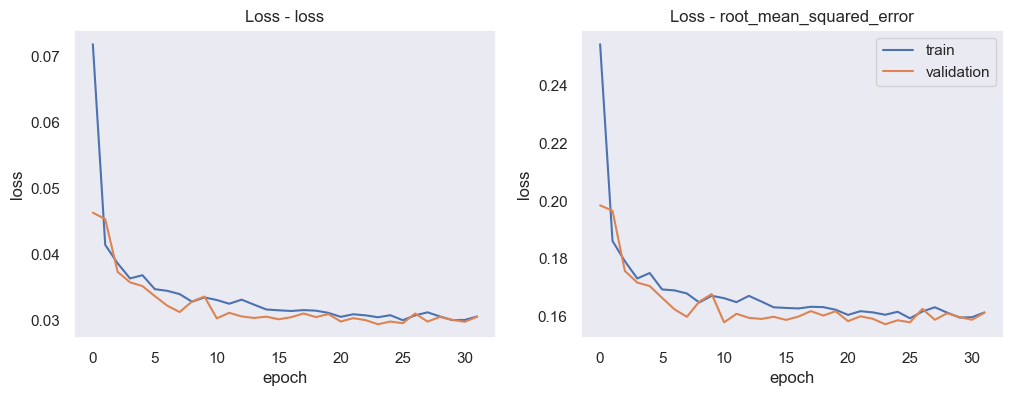

In [308]:
plot(history)

In [310]:
yP = np.array([])
yR = y_test[:].copy()
xR = X_test[:].copy()

yP = model.predict(xR)
PlotSeriesPLY(ySeries=[yR.flatten(),yP.flatten()])

27/27 [==============================] - 0s 10ms/step
